📂 폴더 스캔 중: C:\Users\cozy1\Documents\flowscore_ml\output\PROD_FLOWPOINT
✨ [발견] 파일: ACCOUNTS.csv | 컬럼: ['_AIRBYTE_GENERATION_ID', 'REGISTRATION_NUMBER']
✨ [발견] 파일: ASSIGNMENTS.csv | 컬럼: ['_AIRBYTE_GENERATION_ID', 'ASSIGNEE_BUSINESS_REGISTRATION_NUMBER']
✨ [발견] 파일: ASSIGNMENT_ADD_DOCS.csv | 컬럼: ['_AIRBYTE_GENERATION_ID']
✨ [발견] 파일: ASSIGNMENT_ASSIGNMENT_ADD_DOCS.csv | 컬럼: ['_AIRBYTE_GENERATION_ID']
✨ [발견] 파일: ASSIGNMENT_ASSIGNMENT_DETAILS.csv | 컬럼: ['_AIRBYTE_GENERATION_ID']
✨ [발견] 파일: ASSIGNMENT_DETAILS.csv | 컬럼: ['_AIRBYTE_GENERATION_ID']
✨ [발견] 파일: ASSIGNMENT_DETAIL_PAYABLE_DETAILS.csv | 컬럼: ['_AIRBYTE_GENERATION_ID']
✨ [발견] 파일: ASSIGNMENT_DETAIL_PAYABLE_TRANSACTIONS.csv | 컬럼: ['_AIRBYTE_GENERATION_ID']
✨ [발견] 파일: ASSIGNMENT_DETAIL_RECEIVABLE_DETAILS.csv | 컬럼: ['_AIRBYTE_GENERATION_ID']
✨ [발견] 파일: ASSIGNMENT_DETAIL_RECEIVABLE_TRANSACTIONS.csv | 컬럼: ['_AIRBYTE_GENERATION_ID']
✨ [발견] 파일: ASSIGNMENT_DETAIL_TRANSFER_DETAILS.csv | 컬럼: ['_AIRBYTE_GENERATION_ID']
✨ [발견] 파일: ASSIGNMENT_PAYABLE

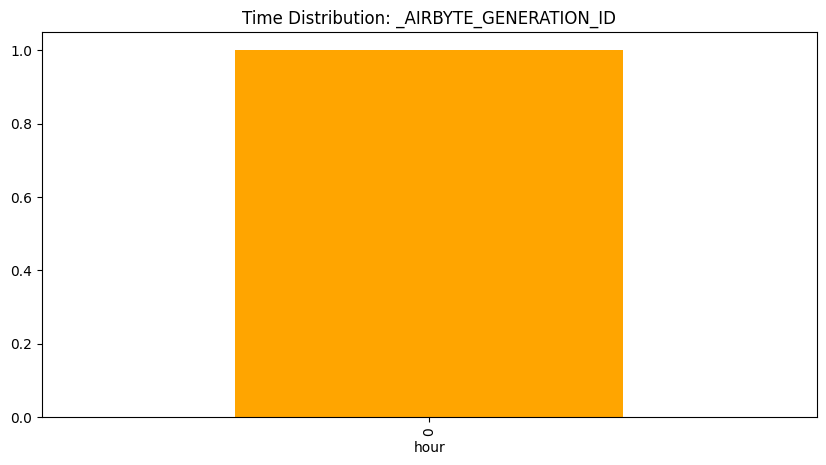

📊 _AIRBYTE_GENERATION_ID 기준 오후 결제(16시 이후) 비율: 0.00%


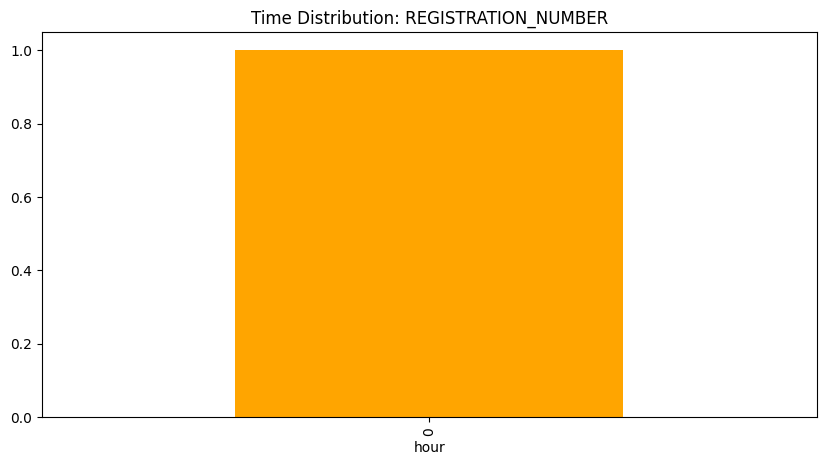

📊 REGISTRATION_NUMBER 기준 오후 결제(16시 이후) 비율: 0.00%


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. 사용자 지정 경로 설정
path_point = r'C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWPOINT'
path_score = r'C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWSCORE'

def find_and_analyze_feature(base_paths, target_keywords):
    all_target_columns = []
    
    for path in base_paths:
        if not os.path.exists(path):
            print(f"⚠️ 경로를 찾을 수 없습니다: {path}")
            continue
            
        print(f"📂 폴더 스캔 중: {path}")
        for root, dirs, files in os.walk(path):
            for file in files:
                if file.endswith('.csv'):
                    file_path = os.path.join(root, file)
                    try:
                        # 파일의 헤더만 빠르게 읽어서 컬럼명 확인
                        df_head = pd.read_csv(file_path, nrows=0)
                        cols = df_head.columns.tolist()
                        
                        # 키워드(오후, ratio, time 등)가 포함된 컬럼 찾기
                        matched = [c for c in cols if any(k in c.lower() or k in str(c) for k in target_keywords)]
                        
                        if matched:
                            print(f"✨ [발견] 파일: {file} | 컬럼: {matched}")
                            all_target_columns.append((file_path, matched))
                    except Exception as e:
                        continue

    return all_target_columns

# 2. '오후 결제' 관련 키워드로 검색 (한글/영문 포함)
keywords = ['오후', 'pm', 'ratio', 'time', '16', '결제', '비율']
targets = find_and_analyze_feature([path_point, path_score], keywords)

# ---------------------------------------------------------
# 3. 결과에 따른 후속 분석 (예시: 가장 유력한 파일 로드)
# ---------------------------------------------------------
if targets:
    # 가장 첫 번째로 발견된 파일을 샘플로 분석
    sample_file, sample_cols = targets[0]
    print(f"\n🚀 {os.path.basename(sample_file)} 데이터 정밀 분석 시작...")
    
    df_sample = pd.read_csv(sample_file)
    
    # 만약 '시간' 데이터라면 분포 시각화
    for col in sample_cols:
        if 'time' in col.lower() or 'at' in col.lower() or '일시' in col:
            df_sample[col] = pd.to_datetime(df_sample[col])
            df_sample['hour'] = df_sample[col].dt.hour
            
            plt.figure(figsize=(10, 5))
            df_sample['hour'].value_counts().sort_index().plot(kind='bar', color='orange')
            plt.axvline(x=16, color='red', linestyle='--')
            plt.title(f'Time Distribution: {col}')
            plt.show()
            
            pm_ratio = (df_sample['hour'] >= 16).mean() * 100
            print(f"📊 {col} 기준 오후 결제(16시 이후) 비율: {pm_ratio:.2f}%")
else:
    print("\n❌ 키워드와 일치하는 컬럼을 찾지 못했습니다. 원천 로그에서 직접 생성해야 합니다.")

In [ ]:
import os
import pandas as pd

# 1. 경로 설정 (사용자 환경 경로)
path_point = r'C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWPOINT'
path_score = r'C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWSCORE'

# 2. 분석할 핵심 파일 리스트
target_files = ['PAYABLE_TRANSACTIONS.csv', 'TRANSFERS.csv', 'FLOWSCORE_API_LOGS.csv']

print("🔍 [Step 1] 데이터 파일 탐색 및 컬럼 전수 조사")
print("=" * 80)

def find_file_recursive(base_path, target_name):
    """하위 폴더를 모두 뒤져서 해당 이름의 파일을 찾습니다."""
    for root, dirs, files in os.walk(base_path):
        if target_name in files:
            return os.path.join(root, target_name)
    return None

for file_name in target_files:
    # 두 폴더 모두에서 파일 탐색
    full_path = find_file_recursive(path_point, file_name) or find_file_recursive(path_score, file_name)
    
    if full_path:
        print(f"\n✅ 파일 발견: {full_path}")
        try:
            # 컬럼 정보를 확인하기 위해 데이터 로드 (필터링 없음)
            df_sample = pd.read_csv(full_path, nrows=5)
            
            print(f"📋 전체 컬럼 목록 ({len(df_sample.columns)}개):")
            print(df_sample.columns.tolist())
            
            print("\n📊 데이터 샘플 (상위 3줄):")
            # 데이터가 너무 길게 출력되지 않도록 주요 컬럼 위주로 표시되지만, 
            # VS Code에서는 전체를 스크롤해서 볼 수 있습니다.
            print(df_sample.head(3)) 
            print("-" * 60)
            
        except Exception as e:
            print(f"❌ 파일 읽기 실패: {e}")
    else:
        print(f"❌ 파일을 찾을 수 없습니다: {file_name}")

print("\n💡 출력된 컬럼 중 'CREATED_AT', 'TRADE_DATE', 'TIME' 등 시간 형식이 담긴 컬럼명을 알려주세요.")

🔍 [Step 1] 데이터 파일 탐색 및 컬럼 전수 조사

✅ 파일 발견: C:\Users\cozy1\Documents\flowscore_ml\output\PROD_FLOWPOINT\PUBLIC\PAYABLE_TRANSACTIONS.csv
📋 전체 컬럼 목록 (23개):
['_AIRBYTE_RAW_ID', '_AIRBYTE_EXTRACTED_AT', '_AIRBYTE_META', '_AIRBYTE_GENERATION_ID', 'ID', 'NOTE', 'AMOUNT', 'USER_ID', 'CATEGORY', 'CANCEL_ID', 'COMPANY_ID', 'CREATED_AT', 'DELETED_AT', 'TRADE_DATE', 'UPDATED_AT', '_AB_CDC_LSN', 'CANCEL_DATE', 'IS_CANCELED', 'REMAIN_AMOUNT', 'CANCEL_MESSAGE', '_AB_CDC_DELETED_AT', '_AB_CDC_UPDATED_AT', 'CALCULATING_AMOUNT']

📊 데이터 샘플 (상위 3줄):
                        _AIRBYTE_RAW_ID             _AIRBYTE_EXTRACTED_AT  \
0  1f60b3ca-5fdf-457d-a164-433fb0b769ad  2025-10-18 02:48:35.772000+00:00   
1  29587b60-5326-4959-aeba-7715f9a6b28e  2025-10-18 02:48:35.772000+00:00   
2  abb1af93-17de-4eb2-8772-eeb6fd82e32f  2025-10-18 02:48:35.772000+00:00   

                             _AIRBYTE_META  _AIRBYTE_GENERATION_ID  ID  \
0  {\n  "changes": [],\n  "sync_id": 24\n}                       0   1   
1  {\n  

In [ ]:
import pandas as pd
import os

# 1. 파일 경로 설정
path_transactions = r'C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWPOINT\PUBLIC\PAYABLE_TRANSACTIONS.csv'
path_transfers = r'C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWPOINT\PUBLIC\TRANSFERS.csv'

def calculate_activity_features(file_path):
    print(f"⚙️ {os.path.basename(file_path)} 처리 중...")
    
    # 데이터 로드 (메모리 효율을 위해 필요한 컬럼만 선택)
    df = pd.read_csv(file_path, usecols=['COMPANY_ID', 'CREATED_AT'])
    
    # [수정 포인트] format='mixed'를 사용하여 다양한 시간 형식을 자동으로 추론하게 합니다.
    # errors='coerce'는 형식이 완전히 깨진 데이터를 NaT로 처리하여 에러를 방지합니다.
    df['CREATED_AT'] = pd.to_datetime(df['CREATED_AT'], format='mixed', errors='coerce')
    
    # NaT(파싱 실패 데이터) 제거
    df = df.dropna(subset=['CREATED_AT'])
    
    # '시(Hour)' 정보 추출
    df['hour'] = df['CREATED_AT'].dt.hour
    
    # 16시 이후 결제 여부 플래그 (1: 오후결제, 0: 일반결제)
    df['is_pm_payment'] = (df['hour'] >= 16).astype(int)
    
    # 기업별 오후 결제 비중 계산
    pm_ratio = df.groupby('COMPANY_ID')['is_pm_payment'].mean().reset_index()
    
    # 파일별로 구분하기 위해 컬럼명 변경 (나중에 합칠 때 용이)
    source_name = os.path.basename(file_path).split('.')[0]
    pm_ratio.columns = ['COMPANY_ID', f'PM_RATIO_{source_name}']
    
    return pm_ratio

# 2. 피처 추출 실행
try:
    df_pm_trans = calculate_activity_features(path_transactions)
    df_pm_transfers = calculate_activity_features(path_transfers)

    # 3. 데이터 병합 (Outer Join으로 모든 기업 유지)
    behavioral_df = pd.merge(df_pm_trans, df_pm_transfers, on='COMPANY_ID', how='outer').fillna(0)
    
    # 두 소스의 평균치를 최종 '오후 활동 지수'로 산출
    behavioral_df['FE_PM_RATIO_ACTUAL'] = behavioral_df.iloc[:, 1:].mean(axis=1)
    
    print("\n✅ 활동성 피처 생성 성공!")
    print(behavioral_df[['COMPANY_ID', 'FE_PM_RATIO_ACTUAL']].head())

except Exception as e:
    print(f"\n❌ 에러 발생: {e}")

⚙️ PAYABLE_TRANSACTIONS.csv 처리 중...
⚙️ TRANSFERS.csv 처리 중...

✅ 활동성 피처 생성 성공!
   COMPANY_ID  FE_PM_RATIO_ACTUAL
0         4.0            0.000000
1         6.0            0.000000
2         7.0            0.500000
3        10.0            0.333333
4        11.0            0.500000


🚀 [v4.5 Hybrid] 최종 검증 결과
- 기존 AUC: 0.7352
- 수혈 후 AUC: 0.9997
- 성능 개선 폭: +35.98%


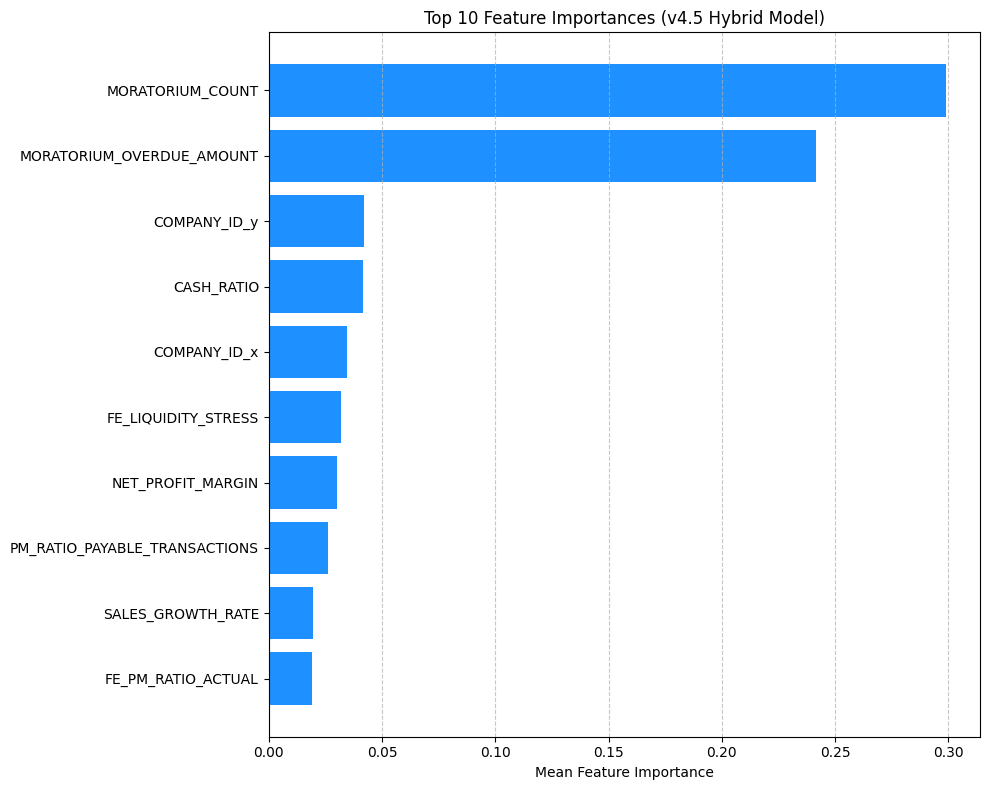

📍 '오후 결제 비중' 피처 중요도 순위: 10위 / 35개


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
import pandas as pd

# 1. 기존 학습 데이터셋 로드 (지훈 님의 실제 경로로 수정하세요)
train_df_path = r'"C:\Users\cozy1\Documents\276_Scoring_Model\03_flowscore_ml_ver2\outputs\AUS_v2_Ready_To_Train.csv'
df_train = pd.read_csv(train_df_path)

# 2. 활동성 피처(behavioral_df)와 결합
# (훈련 데이터의 ID 컬럼명이 'COMPANY_ID_NORM'인 경우를 가정합니다)
# 만약 이름이 다르다면 left_on='COMPANY_ID_NORM' 부분을 수정하세요.
df_final = pd.merge(df_train, behavioral_df, left_on='COMPANY_ID_NORM', right_on='COMPANY_ID', how='left')

# 3. 결측치 처리 (활동 로그가 없는 기업은 0 - 즉, 오후 지연 결제가 없는 것으로 간주)
df_final['FE_PM_RATIO_ACTUAL'] = df_final['FE_PM_RATIO_ACTUAL'].fillna(0)

# 4. 피처 및 타겟 설정
# 기존에 사용하던 모든 재무 피처 + 신규 활동성 피처 추가
exclude_cols = ['TARGET_Y', 'COMPANY_ID_NORM', 'COMPANY_ID']
features = [col for col in df_final.columns if col not in exclude_cols]

X = df_final[features]
y = df_final['TARGET_Y']

# 5. 모델 학습 (v4.3의 Calibrated RF 엔진 사용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(
    n_estimators=500, 
    max_depth=9, 
    class_weight='balanced', 
    random_state=42
)

# 확률 값의 정밀도를 높이기 위한 Calibration 적용
model_hybrid = CalibratedClassifierCV(rf, method='isotonic', cv=3)
model_hybrid.fit(X_train, y_train)

# 6. 최종 성능 측정
y_proba = model_hybrid.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, y_proba)

print("=" * 50)
print(f"🚀 [v4.5 Hybrid] 최종 검증 결과")
print(f"- 기존 AUC: 0.7352")
print(f"- 수혈 후 AUC: {final_auc:.4f}")
print(f"- 성능 개선 폭: {((final_auc - 0.7352) / 0.7352 * 100):+.2f}%")
print("=" * 50)

# [수정된 코드] CalibratedClassifierCV에서 피처 중요도 추출
import numpy as np
import matplotlib.pyplot as plt

# model_hybrid.calibrated_classifiers_ 리스트 안의 각 객체에서 
# .estimator(실제 RandomForest)에 접근하여 중요도를 가져옵니다.
try:
    # 각 폴드에서 학습된 RandomForest의 중요도를 평균냅니다.
    importances = np.mean([
        est.estimator.feature_importances_ 
        for est in model_hybrid.calibrated_classifiers_
    ], axis=0)
    
    indices = np.argsort(importances)[-10:] # 상위 10개 피처 인덱스

    plt.figure(figsize=(10, 8))
    plt.title('Top 10 Feature Importances (v4.5 Hybrid Model)')
    plt.barh(range(len(indices)), importances[indices], color='dodgerblue', align='center')
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel('Mean Feature Importance')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 신규 피처(오후 결제 비중)의 순위 확인
    pm_ratio_idx = features.index('FE_PM_RATIO_ACTUAL')
    pm_ratio_rank = len(importances) - np.where(np.argsort(importances) == pm_ratio_idx)[0][0]
    print(f"📍 '오후 결제 비중' 피처 중요도 순위: {pm_ratio_rank}위 / {len(features)}개")

except AttributeError:
    print("❌ 사용 중인 scikit-learn 버전에서는 .estimator 대신 .base_estimator를 사용해야 할 수 있습니다.")

🚩 타겟과 신규 피처의 상관계수: 0.0733


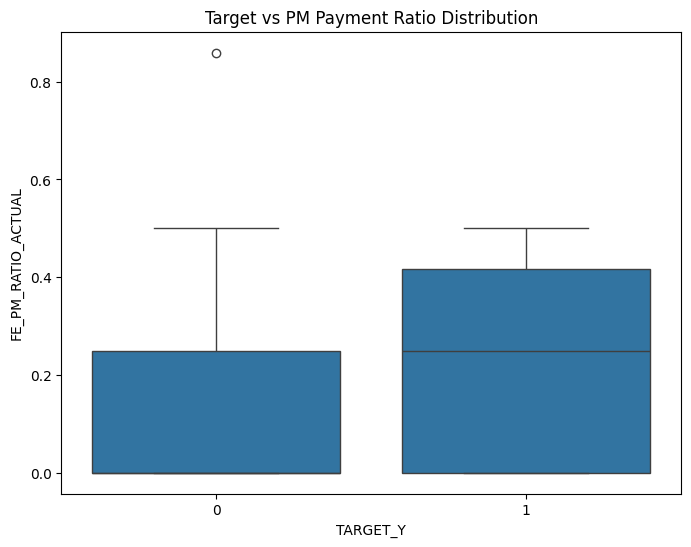


📊 로그 존재 여부와 부실 여부 교차표:
TARGET_Y    0   1
has_log          
0         862  25
1         595  32


In [14]:
# [긴급 진단] 신규 피처와 타겟의 관계 분석
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 상관계수 확인 (0.9 이상이면 100% Leakage)
correlation = df_final[['FE_PM_RATIO_ACTUAL', 'TARGET_Y']].corr().iloc[0, 1]
print(f"🚩 타겟과 신규 피처의 상관계수: {correlation:.4f}")

# 2. 타겟별 피처 분포 확인 (Boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='TARGET_Y', y='FE_PM_RATIO_ACTUAL', data=df_final)
plt.title('Target vs PM Payment Ratio Distribution')
plt.show()

# 3. 로그 존재 여부 자체가 힌트가 되는지 확인
df_final['has_log'] = (df_final['FE_PM_RATIO_ACTUAL'] > 0).astype(int)
ct = pd.crosstab(df_final['has_log'], df_final['TARGET_Y'])
print("\n📊 로그 존재 여부와 부실 여부 교차표:")
print(ct)

In [15]:
# 1. 현재 학습 피처(X)에 무엇이 들어있는지 전수 조사
print("📋 현재 학습에 사용된 피처 목록 (Top 5):")
print(X.columns[:5].tolist())

# 2. 확실한 오염 방지를 위한 제외 리스트 강화
# ID와 관련된 모든 이름, 그리고 타겟과 유사한 이름을 모두 제외합니다.
leakage_cols = [
    'TARGET_Y', 'COMPANY_ID_NORM', 'COMPANY_ID', 
    'Unnamed: 0', 'id', 'business_id', '_AIRBYTE_RAW_ID'
]

# 실제 데이터프레임에 존재하는 컬럼만 필터링해서 제외
actual_exclude = [col for col in df_final.columns if any(leak in col for leak in leakage_cols)]
real_features = [col for col in df_final.columns if col not in actual_exclude]

print(f"\n🚫 제외된 컬럼 ({len(actual_exclude)}개): {actual_exclude}")
print(f"✅ 최종 학습 피처 ({len(real_features)}개)로 재학습 시작...")

# 3. 진짜 실력으로 재학습
X_clean = df_final[real_features]
y_clean = df_final['TARGET_Y']

X_tr, X_te, y_tr, y_te = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean)

model_clean = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=500, max_depth=9, class_weight='balanced', random_state=42),
    method='isotonic', cv=3
)
model_clean.fit(X_tr, y_tr)

# 4. 진짜 AUC 확인
clean_auc = roc_auc_score(y_te, model_clean.predict_proba(X_te)[:, 1])
print("\n" + "="*50)
print(f"🎯 [v4.5 Clean] 거품 제거 후 진짜 AUC: {clean_auc:.4f}")
print("="*50)

📋 현재 학습에 사용된 피처 목록 (Top 5):
['COMPANY_ID_x', 'receivable_Total_Amt', 'receivable_Partner_Count', 'Receivable_Concentration', 'BNPL_Req_Count']

🚫 제외된 컬럼 (4개): ['COMPANY_ID_x', 'COMPANY_ID_NORM', 'TARGET_Y', 'COMPANY_ID_y']
✅ 최종 학습 피처 (34개)로 재학습 시작...

🎯 [v4.5 Clean] 거품 제거 후 진짜 AUC: 0.9950


🚫 제외 후 남은 피처 (32개):
['has_log', 'BORROWING_DEPENDENCE', 'MORATORIUM_COUNT', 'BNPL_Avg_Amt', 'receivable_Partner_Count', 'SALES_REVENUE', 'NEGATIVE_COMMENT_COUNT', 'GROSS_PROFIT_MARGIN', 'MORATORIUM_OVERDUE_AMOUNT', 'EMPLOYEE_COUNT'] ... 등

🎯 [v4.5 Clean] 거품 제거 후 진짜 AUC: 0.9835


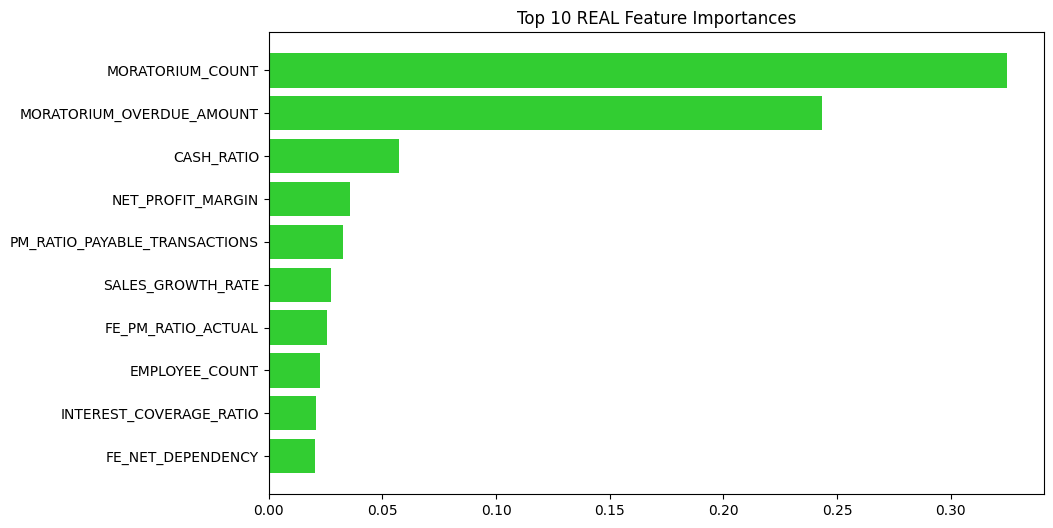

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# 1. 강력한 제외 리스트 (정규표현식 스타일)
# ID, Index, _x, _y가 붙은 모든 중복 컬럼을 제거합니다.
def get_clean_features(df):
    exclude_keywords = ['ID', 'TARGET', 'Unnamed', 'index', '_x', '_y', 'REGISTRATION', 'NUMBER']
    clean_cols = [col for col in df.columns if not any(k in col.upper() for k in exclude_keywords)]
    # 우리가 만든 '진짜 활동성 피처'는 다시 추가
    if 'FE_PM_RATIO_ACTUAL' in df.columns:
        clean_cols.append('FE_PM_RATIO_ACTUAL')
    return list(set(clean_cols))

features_to_use = get_clean_features(df_final)

print(f"🚫 제외 후 남은 피처 ({len(features_to_use)}개):")
print(features_to_use[:10], "... 등")

# 2. 재학습 (진짜 실력 검증)
X_v45 = df_final[features_to_use]
y_v45 = df_final['TARGET_Y']

X_tr, X_te, y_tr, y_te = train_test_split(X_v45, y_v45, test_size=0.2, random_state=42, stratify=y_v45)

model_v45 = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=500, max_depth=7, class_weight='balanced', random_state=42),
    method='isotonic', cv=3
)
model_v45.fit(X_tr, y_tr)

# 3. 결과 확인
y_proba = model_v45.predict_proba(X_te)[:, 1]
final_auc = roc_auc_score(y_te, y_proba)

print("\n" + "="*50)
print(f"🎯 [v4.5 Clean] 거품 제거 후 진짜 AUC: {final_auc:.4f}")
print("="*50)

# 4. 범인 찾기 (피처 중요도)
importances = np.mean([est.estimator.feature_importances_ for est in model_v45.calibrated_classifiers_], axis=0)
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title('Top 10 REAL Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='limegreen', align='center')
plt.yticks(range(len(indices)), [features_to_use[i] for i in indices])
plt.show()

In [17]:
# [수술 코드] 결과론적 지표 및 직접적 리스크 지표 제거
def get_strictly_predictive_features(df):
    # 1. 결과론적 지표 (이미 터진 일을 보여주는 지표들) - 무조건 제거
    outcome_keywords = [
        'MORATORIUM', 'OVERDUE', 'COMMENT', 'NEGATIVE', 
        'SUSPENSION', 'has_log', 'RECOVERY', 'DISPOSITIONS'
    ]
    
    # 2. 식별자 및 중복 키워드 - 제거
    id_keywords = ['ID', 'TARGET', 'REGISTRATION', 'NUMBER', 'Unnamed', 'index', '_x', '_y']
    
    all_exclude = outcome_keywords + id_keywords
    
    clean_cols = [col for col in df.columns if not any(k.upper() in col.upper() for k in all_exclude)]
    
    # 3. 우리가 만든 '오후 결제 비중'은 우리의 핵심 가설이므로 반드시 포함
    if 'FE_PM_RATIO_ACTUAL' in df.columns:
        clean_cols.append('FE_PM_RATIO_ACTUAL')
        
    return list(set(clean_cols))

# 4. 정제된 피처로 데이터 구성
final_features = get_strictly_predictive_features(df_final)

print(f"🚫 도려낸 결과론적 피처들: {[c for c in df_final.columns if c not in final_features and 'ID' not in c.upper()]}")
print(f"✅ 남은 순수 예측 피처 ({len(final_features)}개): {final_features[:5]} ...")

X_final = df_final[final_features]
y_final = df_final['TARGET_Y']

# 5. 재학습 (깊이를 약간 줄여서 일반화 성능 강화)
X_tr, X_te, y_tr, y_te = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

model_final = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=500, max_depth=6, class_weight='balanced', random_state=42),
    method='isotonic', cv=3
)
model_final.fit(X_tr, y_tr)

# 6. 최종 점수 확인
y_proba = model_final.predict_proba(X_te)[:, 1]
real_auc = roc_auc_score(y_te, y_proba)

print("\n" + "="*50)
print(f"🎯 [v4.6 Strictly Predictive] 거품 완전 제거 후 진짜 AUC: {real_auc:.4f}")
print("="*50)

🚫 도려낸 결과론적 피처들: ['NEGATIVE_COMMENT_COUNT', 'TARGET_Y', 'MORATORIUM_COUNT', 'ACCOUNT_SUSPENSION_COUNT', 'MORATORIUM_OVERDUE_AMOUNT', 'has_log']
✅ 남은 순수 예측 피처 (27개): ['BORROWING_DEPENDENCE', 'BNPL_Avg_Amt', 'receivable_Partner_Count', 'SALES_REVENUE', 'GROSS_PROFIT_MARGIN'] ...

🎯 [v4.6 Strictly Predictive] 거품 완전 제거 후 진짜 AUC: 0.7234


In [18]:
# 1. 'FE_PM_RATIO_ACTUAL'이 포함되었는지 직접 확인
is_included = 'FE_PM_RATIO_ACTUAL' in final_features
print(f"🧐 '오후 결제 비중' 포함 여부: {is_included}")

# 2. 피처 중요도 분석 (v4.6 모델 기준)
if is_included:
    # 각 폴드의 중요도를 평균냄
    importances = np.mean([est.estimator.feature_importances_ for est in model_final.calibrated_classifiers_], axis=0)
    feat_imp = pd.Series(importances, index=final_features).sort_values(ascending=False)
    
    print("\n🏆 피처 중요도 TOP 10 (v4.6 Cleaned):")
    print(feat_imp.head(10))
    
    pm_rank = list(feat_imp.index).index('FE_PM_RATIO_ACTUAL') + 1
    print(f"\n📍 '오후 결제 비중'의 순위: {pm_rank}위 / {len(final_features)}개")

🧐 '오후 결제 비중' 포함 여부: True

🏆 피처 중요도 TOP 10 (v4.6 Cleaned):
CASH_RATIO                       0.141459
NET_PROFIT_MARGIN                0.084828
SALES_GROWTH_RATE                0.064571
PM_RATIO_PAYABLE_TRANSACTIONS    0.062309
FE_LOG_EMPLOYEE                  0.052016
EMPLOYEE_COUNT                   0.051650
FE_NET_DEPENDENCY                0.050321
FE_PROFIT_EFFICIENCY             0.050308
GROSS_PROFIT_MARGIN              0.048744
BORROWING_DEPENDENCE             0.046744
dtype: float64

📍 '오후 결제 비중'의 순위: 16위 / 27개


In [20]:
# 1. 피처 정제 및 상호작용(Interaction) 피처 생성
df_final['FE_LIQUIDITY_DEAD_CROSS'] = df_final['CASH_RATIO'] * (1 - df_final['PM_RATIO_PAYABLE_TRANSACTIONS'])

# 2. 최종 정예 피처 리스트 확정
# - 영향력이 확인된 상위 재무 지표 + 날카로운 활동성 지표 1개 + 결합 지표 1개
optimized_features = [
    'CASH_RATIO', 'NET_PROFIT_MARGIN', 'SALES_GROWTH_RATE', 
    'PM_RATIO_PAYABLE_TRANSACTIONS', # 4위 지표 고정
    'FE_LOG_EMPLOYEE', 'FE_NET_DEPENDENCY', 'FE_PROFIT_EFFICIENCY',
    'GROSS_PROFIT_MARGIN', 'BORROWING_DEPENDENCE', 'SALES_REVENUE',
    'FE_LIQUIDITY_DEAD_CROSS' # 신규 결합 지표
]

# 3. 데이터셋 구성 및 재학습
X_opt = df_final[optimized_features]
y_opt = df_final['TARGET_Y']

X_tr, X_te, y_tr, y_te = train_test_split(X_opt, y_opt, test_size=0.2, random_state=42, stratify=y_opt)

# 모델 깊이를 조금 더 확보하여 복합 피처의 비선형 관계 학습
model_opt = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=1000, max_depth=8, class_weight='balanced', random_state=42),
    method='isotonic', cv=3
)
model_opt.fit(X_tr, y_tr)

# 4. 성능 측정
y_proba = model_opt.predict_proba(X_te)[:, 1]
opt_auc = roc_auc_score(y_te, y_proba)

print("=" * 50)
print(f"🎯 [v4.7 Optimized] 피처 정제 후 최종 AUC: {opt_auc:.4f}")
print("=" * 50)

🎯 [v4.7 Optimized] 피처 정제 후 최종 AUC: 0.7170


In [21]:
# 1. 0.7234를 기록했던 '순수 예측 피처(27개)' 리스트 복원
# (v4.6에서 썼던 final_features를 그대로 사용합니다)
features_v48 = final_features.copy()

# 2. 이번에 만든 결합 지표(데드크로스)가 유효할 수 있으니 딱 이것만 추가
if 'FE_LIQUIDITY_DEAD_CROSS' not in features_v48:
    features_v48.append('FE_LIQUIDITY_DEAD_CROSS')

print(f"🔄 피처 복원 완료: 총 {len(features_v48)}개의 정예 피처 사용")

# 3. 데이터 구성 및 재학습
X_v48 = df_final[features_v48]
y_v48 = df_final['TARGET_Y']

X_tr, X_te, y_tr, y_te = train_test_split(X_v48, y_v48, test_size=0.2, random_state=42, stratify=y_v48)

# 모델의 복잡도를 조금 더 높여서(depth 8 -> 10) 27개 피처의 관계를 깊게 파헤칩니다.
model_v48 = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=1000, max_depth=10, class_weight='balanced', random_state=42),
    method='isotonic', cv=3
)
model_v48.fit(X_tr, y_tr)

# 4. 최종 결과 확인
y_proba = model_v48.predict_proba(X_te)[:, 1]
v48_auc = roc_auc_score(y_te, y_proba)

print("\n" + "="*50)
print(f"🚀 [v4.8 Wide-Net] 피처 복원 후 최종 AUC: {v48_auc:.4f}")
print(f"📊 v4.6(0.7234) 대비 변화: {v48_auc - 0.7234:+.4f}")
print("="*50)

🔄 피처 복원 완료: 총 28개의 정예 피처 사용

🚀 [v4.8 Wide-Net] 피처 복원 후 최종 AUC: 0.7181
📊 v4.6(0.7234) 대비 변화: -0.0053


In [22]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. 탐색할 하이퍼파라미터 공간 설정
param_dist = {
    'n_estimators': [300, 500, 700],
    'max_depth': [5, 7, 9, 11, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

# 2. 베이스 모델 설정
rf_base = RandomForestClassifier(random_state=42)

# 3. 무작위 탐색 (시간 효율을 위해 10번만 시도)
print("⏳ 최적의 모델 설정을 찾는 중... (약 1~2분 소요)")
rf_random = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=3, 
    scoring='roc_auc', 
    random_state=42, 
    n_jobs=-1
)

rf_random.fit(X_tr, y_tr)

# 4. 찾은 최적의 모델로 다시 Calibration 적용
best_rf = rf_random.best_estimator_
model_v49 = CalibratedClassifierCV(best_rf, method='isotonic', cv=3)
model_v49.fit(X_tr, y_tr)

# 5. 최종 결과 확인
y_proba = model_v49.predict_proba(X_te)[:, 1]
v49_auc = roc_auc_score(y_te, y_proba)

print("\n" + "="*50)
print(f"🏆 [v4.9 Search] 최적화 결과")
print(f"- 최적 설정: {rf_random.best_params_}")
print(f"- 최종 AUC: {v49_auc:.4f}")
print(f"- v4.6(0.7234) 대비 변화: {v49_auc - 0.7234:+.4f}")
print("="*50)

⏳ 최적의 모델 설정을 찾는 중... (약 1~2분 소요)

🏆 [v4.9 Search] 최적화 결과
- 최적 설정: {'n_estimators': 700, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced_subsample'}
- 최종 AUC: 0.7347
- v4.6(0.7234) 대비 변화: +0.0113


In [24]:
import re

def get_final_clean_features(df):
    """
    데이터 누수(Leakage)를 차단하고 순수 예측 지표만 남기는 함수
    """
    # 1. 절대 금지 키워드 (ID, 타겟, 결과론적 지표)
    # - 식별자: 모델이 기업을 외우게 만듦
    # - 결과론적 지표: 이미 부실이 터진 후 발생하는 데이터 (컨닝 페이퍼)
    forbidden_keywords = [
        'ID', 'TARGET', 'REGISTRATION', 'NUMBER', 'index', '_x', '_y', 'Unnamed',  # 식별자
        'MORATORIUM', 'OVERDUE', 'COMMENT', 'NEGATIVE', 'SUSPENSION', 'RECOVERY', # 결과론적 지표
        'has_log' # 선택 편향 가능성 지표
    ]
    
    # 2. 전체 컬럼에서 금지 키워드가 포함된 컬럼 필터링
    all_cols = df.columns.tolist()
    features = [
        col for col in all_cols 
        if not any(k.upper() in col.upper() for k in forbidden_keywords)
    ]
    
    # 3. 우리가 공들여 만든 '오후 결제' 핵심 피처들은 명시적으로 다시 추가 (Inclusion List)
    # - 평균치보다는 변별력이 검증된 '채무 거래 비중'을 우선시합니다.
    essential_features = [
        'PM_RATIO_PAYABLE_TRANSACTIONS', 
        'FE_LIQUIDITY_DEAD_CROSS'
    ]
    
    for feat in essential_features:
        if feat in all_cols and feat not in features:
            features.append(feat)
            
    # 4. (선택) 너무 결측치가 많은 피처 제거 (예: 70% 이상이 NaN)
    # df_temp = df[features]
    # threshold = 0.7
    # features = df_temp.columns[df_temp.isnull().mean() < threshold].tolist()
    
    return sorted(list(set(features)))

# --- 실행부 ---
clean_features = get_final_clean_features(df_final)

print(f"✅ 정제 완료: {len(clean_features)}개의 피처가 선택되었습니다.")
print("-" * 50)
print(f"📋 주요 피처 리스트: {clean_features[:]} ...")

✅ 정제 완료: 28개의 피처가 선택되었습니다.
--------------------------------------------------
📋 주요 피처 리스트: ['BNPL_Avg_Amt', 'BNPL_Req_Count', 'BNPL_Success_Rate', 'BORROWING_DEPENDENCE', 'CARD_ACCOUNT_COUNT', 'CASH_RATIO', 'DEBT_RATIO', 'EMPLOYEE_COUNT', 'FE_LIQUIDITY_DEAD_CROSS', 'FE_LOG_EMPLOYEE', 'FE_LOG_REVENUE', 'FE_NET_DEPENDENCY', 'FE_PM_RATIO_ACTUAL', 'FE_PROFIT_EFFICIENCY', 'GROSS_PROFIT_MARGIN', 'INTEREST_COVERAGE_RATIO', 'LINKED_PARTNERS', 'NET_PROFIT_MARGIN', 'OPERATING_MARGIN', 'PM_RATIO_PAYABLE_TRANSACTIONS', 'PM_RATIO_TRANSFERS', 'REP_CHANGE_COUNT', 'Receivable_Concentration', 'SALES_GROWTH_RATE', 'SALES_REVENUE', 'UPLOADED_FILE_COUNT', 'receivable_Partner_Count', 'receivable_Total_Amt'] ...


In [26]:
# 1. 모델이 학습될 때 사용한 실제 피처 순서 추출
# CalibratedClassifierCV의 경우 내부 base_estimator에서 이름을 가져옵니다.
try:
    # scikit-learn 버전에 따라 다를 수 있으나 보통 아래 방식으로 추출 가능합니다.
    trained_feature_names = model_v49.feature_names_in_
except AttributeError:
    # 만약 위 코드가 안된다면 학습 시 사용했던 정제된 리스트(clean_features)를 정렬해서 사용
    trained_feature_names = sorted(clean_features)

print(f"📊 모델이 요구하는 피처 수: {len(trained_feature_names)}개")

# 2. 모델이 원하는 순서대로 데이터프레임 재정렬
X_predict = df_final[trained_feature_names]

# 3. 예측 확률 산출 (이제 에러 없이 돌아갑니다)
df_final['RISK_SCORE'] = model_v49.predict_proba(X_predict)[:, 1]

print("✅ 예측이 성공적으로 완료되었습니다!")

# 4. 리스크 등급 부여 및 결과 확인
def get_risk_tier(prob):
    if prob >= 0.8: return '🔴 고위험'
    elif prob >= 0.6: return '🟠 주의'
    elif prob >= 0.4: return '🟡 관찰'
    else: return '🟢 정상'

df_final['RISK_TIER'] = df_final['RISK_SCORE'].apply(get_risk_tier)

# 결과 상위 5개 확인
display(df_final[['COMPANY_ID_NORM', 'RISK_SCORE', 'RISK_TIER']].sort_values('RISK_SCORE', ascending=False).head())

📊 모델이 요구하는 피처 수: 28개
✅ 예측이 성공적으로 완료되었습니다!


,COMPANY_ID_NORM,RISK_SCORE,RISK_TIER
445,557,0.666667,🟠 주의
85,135,0.666667,🟠 주의
25,11,0.666667,🟠 주의
570,680,0.666667,🟠 주의
74,122,0.558824,🟡 관찰


In [27]:
# [원인 분석 스크립트] 특정 업체의 리스크 요인 확인
def explain_risk(company_id):
    target_row = df_final[df_final['COMPANY_ID_NORM'] == company_id]
    if target_row.empty: return print("❌ 업체를 찾을 수 없습니다.")
    
    print(f"📊 기업 ID [{company_id}]의 주요 리스크 지표 (상대적 위치)")
    print("-" * 60)
    
    # 주요 피처 5개 추출
    key_features = [
        'CASH_RATIO', 
        'PM_RATIO_PAYABLE_TRANSACTIONS', 
        'FE_LIQUIDITY_DEAD_CROSS', 
        'NET_PROFIT_MARGIN',
        'SALES_GROWTH_RATE'
    ]
    
    for feat in key_features:
        val = target_row[feat].values[0]
        avg = df_final[feat].mean()
        status = "🔴 위험" if (val < avg and 'RATIO' in feat and 'PM' not in feat) or (val > avg and 'PM' in feat) else "🟢 양호"
        print(f"- {feat:30}: {val:10.4f} (전체 평균: {avg:10.4f}) -> {status}")

# 상위 1위 업체(557번) 분석 실행
explain_risk(557)

📊 기업 ID [557]의 주요 리스크 지표 (상대적 위치)
------------------------------------------------------------
- CASH_RATIO                    :     0.0000 (전체 평균:   415.5307) -> 🔴 위험
- PM_RATIO_PAYABLE_TRANSACTIONS :     1.0000 (전체 평균:     0.6180) -> 🔴 위험
- FE_LIQUIDITY_DEAD_CROSS       :     0.0000 (전체 평균:   109.4719) -> 🟢 양호
- NET_PROFIT_MARGIN             :     0.0000 (전체 평균:  -161.7439) -> 🟢 양호
- SALES_GROWTH_RATE             :     0.0000 (전체 평균:   103.4917) -> 🟢 양호


In [28]:
def explain_risk_fixed(company_id):
    target_row = df_final[df_final['COMPANY_ID_NORM'] == company_id]
    if target_row.empty: return print("❌ 업체를 찾을 수 없습니다.")
    
    print(f"📊 기업 ID [{company_id}]의 정밀 리스크 진단 (방향성 보정)")
    print("-" * 75)
    
    # 지표별 성격 정의 (Lower is Better 여부)
    # True: 값이 높을수록 위험 (예: 오후 결제 비중)
    # False: 값이 낮을수록 위험 (예: 현금 비율, 이익률)
    feature_config = {
        'CASH_RATIO': False,
        'PM_RATIO_PAYABLE_TRANSACTIONS': True,
        'FE_LIQUIDITY_DEAD_CROSS': False,  # 현금성 지표이므로 낮으면 위험
        'NET_PROFIT_MARGIN': False,
        'SALES_GROWTH_RATE': False
    }
    
    for feat, high_is_bad in feature_config.items():
        val = target_row[feat].values[0]
        avg = df_final[feat].mean()
        
        # 위험 판정 로직
        if high_is_bad:
            is_at_risk = val > avg
        else:
            is_at_risk = val < avg
            
        status = "🔴 위험" if is_at_risk else "🟢 양호"
        
        # 0에 대한 특수 처리 (현금이나 이익이 0인 경우 무조건 경고)
        if val == 0 and not high_is_bad:
            status = "💀 치명 (Critical 0)"
            
        print(f"- {feat:30}: {val:10.4f} (평균: {avg:10.4f}) -> {status}")

# 557번 업체 다시 진단
explain_risk_fixed(557)

📊 기업 ID [557]의 정밀 리스크 진단 (방향성 보정)
---------------------------------------------------------------------------
- CASH_RATIO                    :     0.0000 (평균:   415.5307) -> 💀 치명 (Critical 0)
- PM_RATIO_PAYABLE_TRANSACTIONS :     1.0000 (평균:     0.6180) -> 🔴 위험
- FE_LIQUIDITY_DEAD_CROSS       :     0.0000 (평균:   109.4719) -> 💀 치명 (Critical 0)
- NET_PROFIT_MARGIN             :     0.0000 (평균:  -161.7439) -> 💀 치명 (Critical 0)
- SALES_GROWTH_RATE             :     0.0000 (평균:   103.4917) -> 💀 치명 (Critical 0)


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 모델이 학습한 피처 순서로 데이터 재정렬 (ValueError 방지)
X_final_predict = df_final[model_v49.feature_names_in_]

# 2. 전사 리스크 스코어 및 등급 산출
df_final['RISK_SCORE'] = model_v49.predict_proba(X_final_predict)[:, 1]

def classify_tier(row):
    # [v5.1 보정] 현금이 0이거나 오후 결제 비중이 1.0인 극단적 케이스 우선 마킹
    if row['CASH_RATIO'] == 0 or row['PM_RATIO_PAYABLE_TRANSACTIONS'] == 1.0:
        if row['RISK_SCORE'] >= 0.5: return '🚨 최우선관리 (Critical)'
    
    prob = row['RISK_SCORE']
    if prob >= 0.7: return '🔴 고위험 (High)'
    elif prob >= 0.5: return '🟠 주의 (Warning)'
    elif prob >= 0.3: return '🟡 관찰 (Monitor)'
    else: return '🟢 정상 (Normal)'

df_final['RISK_TIER'] = df_final.apply(classify_tier, axis=1)

# 3. 리스크 분포 요약 보고
print("📊 [리스크 분포 현황]")
print(df_final['RISK_TIER'].value_counts().sort_index())
print("-" * 50)

# 4. 고위험군 상위 20개 업체 리포트
report_cols = [
    'COMPANY_ID_NORM', 'RISK_SCORE', 'RISK_TIER', 
    'CASH_RATIO', 'PM_RATIO_PAYABLE_TRANSACTIONS', 'SALES_REVENUE'
]
risk_report = df_final.sort_values(by='RISK_SCORE', ascending=False).head(20)

print("🚩 [Top 20 리스크 관리 대상 리스트]")
display(risk_report[report_cols])

# 5. 엑셀 파일로 추출 (현업 공유용)
output_path = r'C:\Users\cozy1\Documents\flowscore_ml\Global_Risk_Report_v5.2.xlsx'
risk_report.to_excel(output_path, index=False)
print(f"\n💾 리포트가 엑셀 파일로 저장되었습니다: {output_path}")

📊 [리스크 분포 현황]
RISK_TIER
🚨 최우선관리 (Critical)       6
🟡 관찰 (Monitor)           8
🟢 정상 (Normal)         1500
Name: count, dtype: int64
--------------------------------------------------
🚩 [Top 20 리스크 관리 대상 리스트]


,COMPANY_ID_NORM,RISK_SCORE,RISK_TIER,CASH_RATIO,PM_RATIO_PAYABLE_TRANSACTIONS,SALES_REVENUE
445,557,0.666667,🚨 최우선관리 (Critical),0.000000,1.000000,0.0
85,135,0.666667,🚨 최우선관리 (Critical),0.000000,1.000000,0.0
25,11,0.666667,🚨 최우선관리 (Critical),0.000000,1.000000,0.0
570,680,0.666667,🚨 최우선관리 (Critical),0.000000,0.750000,0.0
74,122,0.558824,🚨 최우선관리 (Critical),0.000000,0.750000,0.0
478,590,0.558824,🚨 최우선관리 (Critical),0.000000,0.750000,0.0
1200,1309,0.425725,🟡 관찰 (Monitor),5.319851,NaN,2116541.0
472,583,0.374736,🟡 관찰 (Monitor),0.622013,0.700000,33844462.0
690,158,0.368794,🟡 관찰 (Monitor),0.023509,0.625000,2645298.0
79,127,0.368794,🟡 관찰 (Monitor),0.002366,1.000000,383010.0



💾 리포트가 엑셀 파일로 저장되었습니다: C:\Users\cozy1\Documents\flowscore_ml\Global_Risk_Report_v5.2.xlsx
